# HW4 — Neural Grammars: Discovering the World's Visual Alphabet with VQ-VAE-2

---

## 📌 Project Outline

In this notebook you will build a **Hierarchical VQ-VAE-2** trained on the **Omniglot** dataset — a collection of handwritten characters from 50 world alphabets.

The model learns to decompose every character into **discrete visual atoms** at two complementary levels:
- **Top latent** → global topology (skeleton / letter identity)
- **Bottom latent** → fine stroke details (pen pressure, thickness)

### What you will build, section by section

| # | Section | New Concept |
|---|---------|-------------|
| 1 | Dataset & Setup | Omniglot pipeline, reproducibility |
| 2 | Residual Stack | Residual blocks with skip connections |
| 3 | Encoder & Decoder | Stride-aware modular blocks |
| 4 | Vector Quantizer (EMA) | **Vectorised L2**, EMA codebook, **STE** |
| 5 | VQ-VAE-2 Wrapper | Hierarchical two-level architecture |
| 6 | Training Loop | Mixed-precision, SSIM, results table |
| 7 | FID Evaluation | Fréchet Inception Distance |
| 8 | Error Heatmaps | Pixel-wise visual analytics |
| 9 | Hierarchical Probing | Top-only vs full reconstruction |

### Grading
| Section | Topic | Points |
|---------|-------|--------|
| 4 | Vectorised distance · EMA · STE | 25 |
| 5 | Hierarchical architecture | 25 |
| 6 | Training loop · SSIM · results table | 20 |
| 7–9 | FID · heatmaps · probing | 30 |
| **Total** | | **100** |

### ⚠️ Hard Rules
1. **Forbidden**: `torch.cdist`, `torch.norm`, any Python loop for distance computation.
2. **Required**: Straight-Through Estimator (STE) for gradient flow through quantisation.
3. **Required**: EMA codebook updates — no optimiser may touch the embeddings.
4. **Required**: Print a standardised results table at the end of every epoch.

---
📥 **Dataset**: Download Omniglot from [Kaggle](https://www.kaggle.com/datasets/qweenink/omniglot) and unzip to `./omniglot/`.

---
## Section 1 — Dataset & Reproducibility Setup

### New concept: Omniglot data pipeline

Omniglot images are **105 × 105 grayscale**. We resize to **64 × 64** so the two-level hierarchy produces spatial grids of 16 × 16 (Bottom) and 8 × 8 (Top), which are convenient powers of two.

Normalising to **[−1, 1]** (mean 0.5, std 0.5) centres the data symmetrically, which helps the decoder's final `tanh` activation.

We also fix the global random seed here so that all students reproduce the same weight initialisations and data shuffling.

Using device: cuda
Dataset size : 19280 images
Batches/epoch: 151


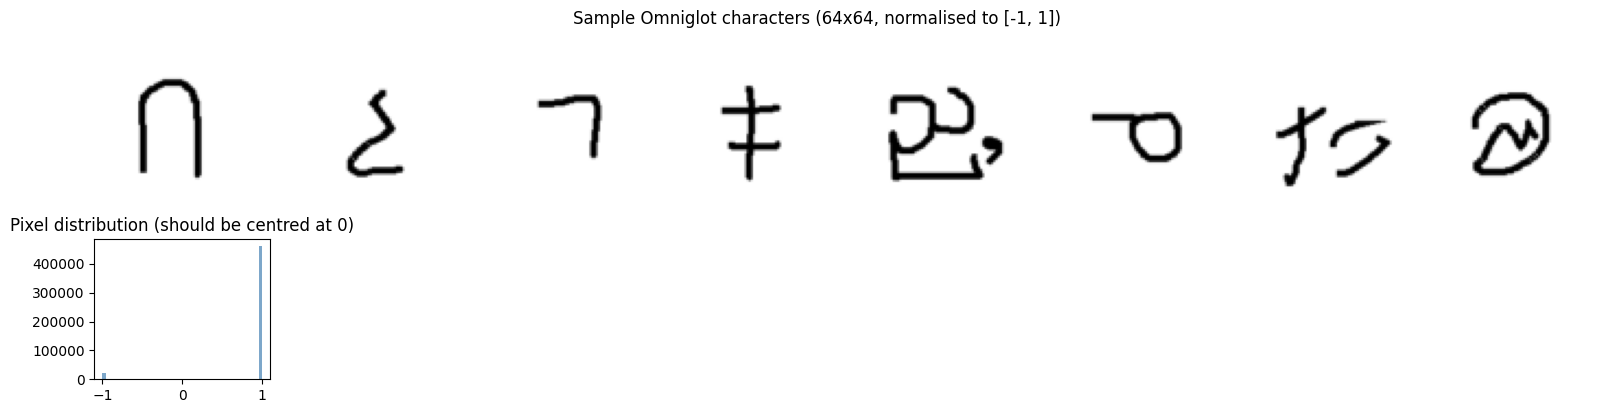

Pixel stats: mean=0.838 (expected ~0.0), std=0.502 (expected ~0.5)


In [1]:
# --- TEACHER CODE: Section 1 ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Updated path for Colab/Local environments
OMNIGLOT_ROOT = './omniglot_data'

def get_dataloader(root=OMNIGLOT_ROOT, batch_size=128):
    """Return a DataLoader for the Omniglot background split."""
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),   # maps [0,1] to [-1,1]
    ])
    
    # Use torchvision's built-in downloader if the folder doesn't exist
    dataset = datasets.Omniglot(root=root, background=True, download=True, transform=transform)
    
    return DataLoader(dataset, batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=True)

train_loader = get_dataloader()
print(f'Dataset size : {len(train_loader.dataset)} images')
print(f'Batches/epoch: {len(train_loader)}')

# Sanity check: visualise one batch + pixel distribution
imgs, _ = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for ax, img in zip(axes[0], imgs[:8]):
    ax.imshow(img.squeeze(), cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
axes[0, 0].set_ylabel('Images', fontsize=10)
axes[1, 0].hist(imgs.numpy().ravel(), bins=50, color='steelblue', alpha=0.7)
axes[1, 0].set_title('Pixel distribution (should be centred at 0)')
for ax in axes[1, 1:]:
    ax.axis('off')
plt.suptitle('Sample Omniglot characters (64x64, normalised to [-1, 1])', y=1.02)
plt.tight_layout(); plt.show()
print(f'Pixel stats: mean={imgs.mean():.3f} (expected ~0.0), std={imgs.std():.3f} (expected ~0.5)')

---
## Section 2 — Residual Stack

### New concept: Residual connections

A **Residual Block** allows gradients to flow directly through an identity shortcut, preventing vanishing gradients in deeper encoders.  
The block applies:
$$
\text{out} = x + \text{Conv}_{1\times1}\bigl(\text{ReLU}(\text{Conv}_{3\times3}(\text{ReLU}(x)))\bigr)
$$

Notice that **no bias** is used inside the residual path — when combined with batch/layer normalisation this is standard practice for stable training.

A `ResidualStack` simply chains `num_residual_layers` of these blocks.

In [2]:
# Section 2 — Residual Stack
# TODO: Implement ResidualBlock
# - A single residual block: ReLU -> Conv2d(3x3) -> ReLU -> Conv2d(1x1)
# - The output is the sum of the input (identity skip) and the block output
# - Use no bias in the conv layers
# Args:
#   in_channels          (int): number of input channels
#   num_hiddens          (int): number of output channels (must equal in_channels for the skip add)
#   num_residual_hiddens (int): bottleneck channels inside the 3x3 conv

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        super().__init__()
        # TODO: define self.block as an nn.Sequential of
        #       ReLU -> Conv2d(3x3, bottleneck) -> ReLU -> Conv2d(1x1, num_hiddens)
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(
                in_channels, 
                num_residual_hiddens, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                bias=False
            ),
            nn.ReLU(),
            nn.Conv2d(
                num_residual_hiddens, 
                num_hiddens, 
                kernel_size=1, 
                stride=1, 
                bias=False
            )
        )

    def forward(self, x):
        return x + self.block(x)


# TODO: Implement ResidualStack
# - Stack of num_residual_layers ResidualBlocks followed by a final ReLU
# Args:
#   in_channels          (int): input channels
#   num_hiddens          (int): hidden channels
#   num_residual_layers  (int): number of ResidualBlock layers to stack
#   num_residual_hiddens (int): bottleneck channels

class ResidualStack(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens):
        super().__init__()
        # TODO: build self.layers as nn.Sequential of num_residual_layers ResidualBlocks
        self.layers = nn.Sequential(*[
            ResidualBlock(in_channels, num_hiddens, num_residual_hiddens)
            for _ in range(num_residual_layers)
        ])

    def forward(self, x):
        # TODO: pass x through self.layers and apply F.relu
        return F.relu(self.layers(x))


# --- Sanity check (do not modify) ---
dummy = torch.randn(4, 128, 16, 16, requires_grad=True)
stack = ResidualStack(128, 128, 2, 32)
out   = stack(dummy)
assert out.shape == dummy.shape, f'Shape mismatch: {out.shape}'
out.sum().backward()
assert dummy.grad is not None and dummy.grad.abs().sum() > 0, 'Gradient did not flow!'
print('ResidualStack OK')
print(f'  Output shape:        {out.shape}')
print(f'  Gradient norm:       {dummy.grad.norm().item():.4f}  (must be > 0)')


ResidualStack OK
  Output shape:        torch.Size([4, 128, 16, 16])
  Gradient norm:       273.8241  (must be > 0)


---
## Section 3 — Modular Scale-Aware Encoder & Decoder

### New concept: Stride-parameterised convolutions

The two-level hierarchy needs two encoders with **different spatial strides**:

| Module | Stride | Input (64²) | Output |
|--------|--------|-------------|--------|
| `enc_b` (Bottom) | 4 | 64 × 64 | 16 × 16 |
| `enc_t` (Top)    | 2 | 16 × 16 |  8 × 8  |

Stride-4 is implemented as **two** consecutive stride-2 `Conv2d` layers (better gradient flow than one stride-4 layer).  
The decoder mirrors this with `ConvTranspose2d` for upsampling.

> **Architecture tip (optional variation):** You can insert a 1×1 projection conv before the residual stack to decouple the channel width from the strided conv's output channels.

In [3]:
# Section 3 — Modular Scale-Aware Encoder & Decoder

# TODO: Implement Encoder
# - stride=4: two consecutive stride-2 Conv2d layers (better gradient flow than one stride-4)
# - stride=2: one stride-2 Conv2d layer
# - Both are followed by a ResidualStack
# - Raise ValueError for any other stride value
# Args:
#   in_channels          (int): input image channels
#   num_hiddens          (int): feature channels
#   num_residual_layers  (int): residual blocks
#   num_residual_hiddens (int): bottleneck channels
#   stride               (int): 2 or 4

class Encoder(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers,
                 num_residual_hiddens, stride, conv_out_channels=64):
        super().__init__()
        # TODO: define self.conv based on stride (4 or 2)
        # TODO: define self.res_stack as a ResidualStack
        if stride == 4:
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels, conv_out_channels, kernel_size=4, stride=2, padding=1),
                nn.ReLU(),
                nn.Conv2d(conv_out_channels, conv_out_channels, kernel_size=4, stride=2, padding=1)
            )
        else :
            self.conv = nn.Conv2d(in_channels, conv_out_channels, kernel_size=4, stride=2, padding=1)

        self.proj = nn.Conv2d(conv_out_channels, num_hiddens, kernel_size=1)
        
        self.res_stack = ResidualStack(
            in_channels=num_hiddens,
            num_hiddens=num_hiddens,
            num_residual_layers=num_residual_layers,
            num_residual_hiddens=num_residual_hiddens
        )

    def forward(self, x):
        return self.res_stack(self.proj(self.conv(x)))
        


# TODO: Implement Decoder
# - Mirrors Encoder using ConvTranspose2d for upsampling
# - stride=4: 1x1 projection + ResidualStack + two stride-2 ConvTranspose2d layers
# - stride=2: 1x1 projection + ResidualStack + one stride-2 ConvTranspose2d layer
# - Raise ValueError for any other stride value
# Args:
#   in_channels          (int): input channels to the decoder (may differ from num_hiddens)
#   num_hiddens          (int): feature channels
#   num_residual_layers  (int): residual blocks
#   num_residual_hiddens (int): bottleneck channels
#   stride               (int): 2 or 4
#   out_channels         (int): final output channels (default: 1 for grayscale)

class Decoder(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers,
                 num_residual_hiddens, stride, out_channels=1):
        super().__init__()
        # TODO: define self.proj  (1x1 conv: in_channels -> num_hiddens)
        # TODO: define self.res_stack as a ResidualStack
        # TODO: define self.upsample based on stride (4 or 2)
        self.proj = nn.Conv2d(in_channels, num_hiddens, kernel_size=1)
        
        self.res_stack = ResidualStack(
            in_channels=num_hiddens,
            num_hiddens=num_hiddens,
            num_residual_layers=num_residual_layers,
            num_residual_hiddens=num_residual_hiddens
        )
        
        if stride == 2:
            self.upsample = nn.ConvTranspose2d(
                num_hiddens, out_channels, 
                kernel_size=4, stride=2, padding=1
            )
        else:
            self.upsample = nn.Sequential(
                nn.ConvTranspose2d(num_hiddens, num_hiddens, kernel_size=4, stride=2, padding=1),
                nn.ReLU(),
                nn.ConvTranspose2d(num_hiddens, out_channels, kernel_size=4, stride=2, padding=1)
            )

    def forward(self, x):
        # TODO: return self.upsample(self.res_stack(self.proj(x)))
        return self.upsample(self.res_stack(self.proj(x)))


# --- Sanity check (do not modify) ---
enc_b = Encoder(1,   128, 2, 32, stride=4)
enc_t = Encoder(128, 128, 2, 32, stride=2)
dec_b = Decoder(128, 128, 2, 32, stride=4, out_channels=1)

x   = torch.zeros(2, 1, 64, 64)
z_b = enc_b(x)
z_t = enc_t(z_b)
print(f'enc_b output z_b: {z_b.shape}  (expected [2,128,16,16])')
print(f'enc_t output z_t: {z_t.shape}  (expected [2,128, 8, 8])')
recon = dec_b(torch.zeros(2, 128, 16, 16))
print(f'dec_b output    : {recon.shape}  (expected [2,  1,64,64])')


enc_b output z_b: torch.Size([2, 128, 16, 16])  (expected [2,128,16,16])
enc_t output z_t: torch.Size([2, 128, 8, 8])  (expected [2,128, 8, 8])
dec_b output    : torch.Size([2, 1, 64, 64])  (expected [2,  1,64,64])


---
## Section 4 — Vector Quantizer with EMA (The Discrete Bottleneck)

### New concepts: vectorised L2 distance · EMA codebook · Straight-Through Estimator

#### 4.1 Why quantise?
The quantiser maps a continuous latent vector to the nearest entry in a learned **codebook** of `K` embeddings, creating a *discrete* bottleneck.  
The problem: `argmin` is not differentiable.

#### 4.2 Vectorised L2 distance (mandatory formula)
Given a flat batch of encoder outputs $Z \in \mathbb{R}^{N \times D}$ and codebook $E \in \mathbb{R}^{K \times D}$:
$$
\|z_i - e_k\|^2 = \|z_i\|^2 + \|e_k\|^2 - 2\,z_i \cdot e_k^\top
$$
This gives the full $N \times K$ distance matrix in a **single matrix multiply** — no loops, no `cdist`.

#### 4.3 Straight-Through Estimator (STE)
Because `argmin` has zero gradient almost everywhere, we use the STE trick:
```python
quantized = z + (quantized - z).detach()
```
In the forward pass, `quantized` (the codebook vector) is used.  
In the backward pass, gradients flow *straight through* to `z` as if no quantisation occurred.

#### 4.4 EMA Codebook Update
Instead of letting an optimiser update the embeddings (which causes instability), we use **Exponential Moving Average**:
$$
N_k \leftarrow \gamma N_k + (1-\gamma)\,n_k, \qquad
m_k \leftarrow \gamma m_k + (1-\gamma)\,\sum_{z\in C_k} z
$$
$$
e_k \leftarrow \frac{m_k}{N_k + \epsilon}
$$
where $n_k$ is the count of vectors assigned to cluster $k$ and $\epsilon=10^{-5}$ prevents division by zero (Laplace smoothing).

In [4]:
# Section 4 — Vector Quantizer with EMA (The Discrete Bottleneck)

# TODO: Implement VectorQuantizerEMA
#
# The quantiser maps continuous latent vectors to the nearest codebook entry,
# creating a discrete bottleneck. Gradients are passed through the STE trick.
#
# Requirements (strictly enforced):
#   1. Vectorised L2 distance:  ||z - e||^2 = ||z||^2 + ||e||^2 - 2 * z @ e^T
#      NO torch.cdist, NO torch.norm, NO Python loops for distance computation
#   2. Straight-Through Estimator (STE) for gradient flow through argmin
#   3. EMA codebook updates — the optimizer must NOT touch the embeddings
#   4. Laplace smoothing (epsilon=1e-5) in the EMA denominator
#
# Args:
#   num_embeddings  (int)  : codebook size K
#   embedding_dim   (int)  : dimension D of each embedding vector
#   commitment_cost (float): beta, weight of the commitment loss
#   decay           (float): EMA decay gamma
#                            *** Use 0.95 (not 0.99) for Omniglot. ***
#                            A decay of 0.99 updates the codebook too slowly
#                            on small datasets, causing codebook collapse where
#                            only a handful of codes are ever used.
#
# Forward input:  (B, D, H, W)
# Forward output: (commitment_loss, quantized (B,D,H,W), perplexity scalar)

class VectorQuantizerEMA(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay=0.95):
        super().__init__()
        self.K     = num_embeddings
        self.D     = embedding_dim
        self.beta  = commitment_cost
        self.decay = decay

        # TODO: initialise codebook buffers with register_buffer
        # Hint: use register_buffer for 'embeddings', 'ema_cluster_size', 'ema_w'
        # so they move with .to(device) but are NOT trainable parameters.
        #
        # Important: initialise ema_cluster_size to ones (not zeros).
        # Starting at zero causes near-zero division in the first EMA update,
        # which corrupts the embeddings before training even begins.
        embeddings = torch.randn(self.K, self.D)
        nn.init.uniform_(embeddings, -1.0 / self.K, 1.0 / self.K)
        self.register_buffer('embeddings', embeddings)
        
        self.register_buffer('ema_cluster_size', torch.ones(self.K))
        self.register_buffer('ema_w', self.embeddings.clone())

    def forward(self, inputs):
        # Step 1: Flatten spatial dims: (B,D,H,W) -> (N,D) where N=B*H*W
        # TODO: permute to (B,H,W,D) then reshape to (N,D)

        # Step 2: Vectorised L2 distance -> (N, K) matrix
        # TODO: compute using ||z||^2 + ||e||^2 - 2*z@e^T  (NO cdist / norm / loops)

        # Step 3: Nearest-neighbour lookup
        # TODO: indices = argmin over K dimension
        # TODO: encodings = one_hot(indices, K).float()

        # Step 4: Quantised vectors
        # TODO: quantized = encodings @ embeddings, then reshape to (B,H,W,D)

        # Step 5: EMA codebook update (training only)
        # TODO: if self.training:
        #   - update ema_cluster_size with EMA of cluster counts
        #   - update ema_w with EMA of summed encoder outputs per cluster
        #   - update embeddings = ema_w / (ema_cluster_size + 1e-5)

        # Step 6: Commitment loss + Straight-Through Estimator
        # TODO: loss = beta * MSE(quantized.detach(), z)   <- encoder moves toward codebook
        # TODO: quantized_st = z + (quantized - z).detach()  <- STE
        # TODO: permute quantized_st back to (B,D,H,W)

        # Step 7: Perplexity
        # TODO: avg_probs = encodings.mean(0)
        # TODO: perplexity = exp(-sum(avg_probs * log(avg_probs + 1e-10)))

        # TODO: return loss, quantized_st, perplexity
        B, D, H, W = inputs.shape
        inputs_permuted = inputs.permute(0, 2, 3, 1).contiguous()
        z = inputs_permuted.view(-1, self.D) 

        z_sq = torch.sum(z ** 2, dim=1, keepdim=True)      
        e_sq = torch.sum(self.embeddings ** 2, dim=1)      
        distances = z_sq + e_sq - 2 * torch.matmul(z, self.embeddings.t()) 

        indices = torch.argmin(distances, dim=1)
        encodings = torch.zeros(indices.shape[0], self.K, device=inputs.device)
        encodings.scatter_(1, indices.unsqueeze(1), 1.0) 

        quantized = torch.matmul(encodings, self.embeddings).view(B, H, W, D)

        if self.training:
            n_k = torch.sum(encodings, dim=0) 
            m_k = torch.matmul(encodings.t(), z) 
            
            self.ema_cluster_size.mul_(self.decay).add_(n_k, alpha=1 - self.decay)
            self.ema_w.mul_(self.decay).add_(m_k, alpha=1 - self.decay)
            
            self.embeddings.copy_(self.ema_w / (self.ema_cluster_size.unsqueeze(1) + 1e-5))

        commitment_loss = self.beta * torch.mean((quantized.detach() - inputs_permuted) ** 2)
        
        quantized_st = inputs_permuted + (quantized - inputs_permuted).detach()
        quantized_st = quantized_st.permute(0, 3, 1, 2).contiguous()

        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return commitment_loss, quantized_st, perplexity


# --- Sanity checks (do not modify) ---
# Note: these checks will raise AttributeError if your __init__ does not
# call register_buffer('embeddings', ...) — that is the expected failure mode.
print('=== VectorQuantizerEMA Sanity Checks ===')

vq = VectorQuantizerEMA(num_embeddings=512, embedding_dim=64, commitment_cost=0.25)
dummy_z = torch.randn(4, 64, 8, 8)
loss_vq, q, perp = vq(dummy_z)
assert q.shape == dummy_z.shape, f'Shape mismatch: {q.shape}'
print(f'[OK] Output shape matches input: {q.shape}')
print(f'[OK] commitment_loss: {loss_vq.item():.4f}')
print(f'[OK] perplexity: {perp.item():.2f}  (range: 1 to {vq.K})')

# STE: gradient must flow to the encoder output
dummy_z2 = torch.randn(4, 64, 8, 8, requires_grad=True)
vq2 = VectorQuantizerEMA(512, 64, 0.25)
_, q2, _ = vq2(dummy_z2)
q2.sum().backward()
assert dummy_z2.grad is not None, 'STE FAILED: no gradient at encoder output!'
print(f'[OK] STE works: gradient norm at encoder = {dummy_z2.grad.norm():.4f}')

# EMA: embeddings must change during training forward pass
vq3 = VectorQuantizerEMA(16, 8, 0.25)
vq3.train()
emb_before = vq3.embeddings.clone()
vq3(torch.randn(8, 8, 4, 4))
assert not torch.allclose(vq3.embeddings, emb_before), 'EMA update not working!'
print('[OK] EMA updates embeddings during training')

# Embeddings must NOT be trainable parameters
param_names = [n for n, _ in vq.named_parameters()]
assert 'embeddings' not in param_names
print('[OK] Embeddings are buffers, not trainable parameters')


=== VectorQuantizerEMA Sanity Checks ===
[OK] Output shape matches input: torch.Size([4, 64, 8, 8])
[OK] commitment_loss: 0.2493
[OK] perplexity: 182.22  (range: 1 to 512)
[OK] STE works: gradient norm at encoder = 128.0000
[OK] EMA updates embeddings during training
[OK] Embeddings are buffers, not trainable parameters


---
## Section 5 — Hierarchical VQ-VAE-2 Wrapper

### New concept: Conditioning Bottom on Top

The key insight of VQ-VAE-2 is that the **Bottom level is conditioned on the Top level**.
After quantising the Top latent $q_t$, we upsample it back to the Bottom's spatial resolution and **concatenate** it with the Bottom quantised latent $q_b$ before decoding:

```
Image (1×64×64)
    │
    ▼
 enc_b  →  z_b (128×16×16)
              │
           enc_t  →  z_t (128×8×8)  →  vq_t  →  q_t  →  upsample  ─┐
              │                                                        │ cat
           vq_b  →  q_b (64×16×16) ──────────────────────────────────┘
              │
           dec_b  →  x̂ (1×64×64)
```

**Note on channels:** `vq_t` and `vq_b` use `embedding_dim=64`, while encoders output `num_hiddens=128`.  
A 1×1 `pre_vq_conv` projects 128 → 64 before each quantiser.

In [5]:
# Section 5 — Hierarchical VQ-VAE-2 Wrapper

# TODO: Implement VQVAE2
#
# Architecture summary:
#   Image (1×64×64)
#       |
#      enc_b  ->  z_b (H×16×16)
#                  |
#               enc_t  ->  z_t (H×8×8)  ->  vq_t  ->  q_t  ->  upsample  --+
#                  |                                                          | cat
#               vq_b  ->  q_b (D×16×16) -----------------------------------+
#                  |
#               dec_b  ->  x_hat (1×64×64)
#
# Notes:
#   - pre_vq_t and pre_vq_b are 1x1 convolutions projecting H -> D channels
#   - upsample_t is a ConvTranspose2d that upsamples q_t from 8x8 to 16x16
#   - dec_b input is cat([q_t_up, q_b]) = D*2 channels at 16x16
#
# Args:
#   num_hiddens         (int): encoder/decoder feature channels (128)
#   num_residual_layers (int): residual blocks per stack (2)
#   num_residual_hid    (int): bottleneck channels in residual block (32)
#   num_embeddings      (int): codebook size K (128 for Omniglot)
#   embedding_dim       (int): codebook vector dimension D (64)
#
# Forward input:  (B, 1, 64, 64)
# Forward output: (total_vq_loss, recon, perp_top, perp_bot)

class VQVAE2(nn.Module):
    def __init__(self, num_hiddens=128, num_residual_layers=2,
                 num_residual_hid=32, num_embeddings=128, embedding_dim=64):
        super().__init__()
        H, D = num_hiddens, embedding_dim

        # TODO: define enc_b (stride=4, input channels=1)
        # TODO: define enc_t (stride=2, input channels=H)

        # TODO: define pre_vq_t and pre_vq_b
        #       Each should be a 1x1 Conv2d projecting H -> D channels,
        #       followed by a LayerNorm over the [D, H_spatial, W_spatial] dims.
        #       (Top spatial size: 8x8 — so LayerNorm([D, 8, 8])
        #        Bottom spatial size: 16x16 — so LayerNorm([D, 16, 16]))
        #       Without normalisation, the encoder's output scale grows during
        #       training and all vectors cluster into one codebook region → collapse.

        # TODO: define vq_t and vq_b
        #       Use VectorQuantizerEMA with commitment_cost=0.25 and decay=0.95

        # TODO: define upsample_t (ConvTranspose2d: D -> D, kernel 4, stride 2, padding 1)

        # TODO: define dec_b (input channels = D*2, stride=4, out_channels=1)
        self.enc_b = Encoder(1, H, num_residual_layers, num_residual_hid, stride=4)
        self.enc_t = Encoder(H, H, num_residual_layers, num_residual_hid, stride=2)

        self.pre_vq_t = nn.Sequential(
            nn.Conv2d(H, D, kernel_size=1),
            nn.LayerNorm([D, 8, 8])
        )
        self.pre_vq_b = nn.Sequential(
            nn.Conv2d(H, D, kernel_size=1),
            nn.LayerNorm([D, 16, 16])
        )

        self.vq_t = VectorQuantizerEMA(num_embeddings, D, commitment_cost=0.25, decay=0.95)
        self.vq_b = VectorQuantizerEMA(num_embeddings, D, commitment_cost=0.25, decay=0.95)

        self.upsample_t = nn.ConvTranspose2d(D, D, kernel_size=4, stride=2, padding=1)

        self.dec_b = Decoder(D * 2, H, num_residual_layers, num_residual_hid, stride=4, out_channels=1)

    def forward(self, x):
        # TODO: encode bottom level: z_b = enc_b(x)
        # TODO: encode top level:    z_t = enc_t(z_b)

        # TODO: quantise top:    loss_t, q_t, perp_t = vq_t(pre_vq_t(z_t))
        # TODO: quantise bottom: loss_b, q_b, perp_b = vq_b(pre_vq_b(z_b))

        # TODO: upsample q_t from 8x8 to 16x16
        # TODO: decode:  recon = dec_b(cat([q_t_up, q_b], dim=1))

        # TODO: return (loss_t + loss_b, recon, perp_t, perp_b)
        z_b = self.enc_b(x)
        z_t = self.enc_t(z_b)

        loss_t, q_t, perp_t = self.vq_t(self.pre_vq_t(z_t))
        loss_b, q_b, perp_b = self.vq_b(self.pre_vq_b(z_b))

        q_t_up = self.upsample_t(q_t)
        
        recon = self.dec_b(torch.cat([q_t_up, q_b], dim=1))

        return loss_t + loss_b, recon, perp_t, perp_b


# --- Sanity checks (do not modify) ---
print('=== VQVAE2 Sanity Checks ===')
model = VQVAE2().to(device)
x_dummy = torch.randn(4, 1, 64, 64).to(device)
vq_loss, recon, pt, pb = model(x_dummy)

assert recon.shape == x_dummy.shape
print(f'[OK] Reconstruction shape: {recon.shape}')
print(f'[OK] VQ loss:             {vq_loss.item():.4f}')
print(f'[OK] Perplexity Top/Bot:  {pt.item():.1f} / {pb.item():.1f}')

total_params  = sum(p.numel() for p in model.parameters())
total_buffers = sum(b.numel() for b in model.buffers())
print(f'Model parameters:  {total_params:,}  (trained by optimizer)')
print(f'Codebook buffers:  {total_buffers:,}  (updated by EMA only)')

with torch.no_grad():
    zb = model.enc_b(x_dummy)
    zt = model.enc_t(zb)
print(f'Bottom grid: {zb.shape[2]}x{zb.shape[3]} = {zb.shape[2]*zb.shape[3]} codes per image')
print(f'Top    grid: {zt.shape[2]}x{zt.shape[3]} = {zt.shape[2]*zt.shape[3]} codes per image')
print(f'Total codes per image: {zb.shape[2]*zb.shape[3] + zt.shape[2]*zt.shape[3]}')


=== VQVAE2 Sanity Checks ===
[OK] Reconstruction shape: torch.Size([4, 1, 64, 64])
[OK] VQ loss:             0.4975
[OK] Perplexity Top/Bot:  2.0 / 6.7
Model parameters:  864,129  (trained by optimizer)
Codebook buffers:  33,024  (updated by EMA only)
Bottom grid: 16x16 = 256 codes per image
Top    grid: 8x8 = 64 codes per image
Total codes per image: 320


---
## Section 6 — Training Loop, SSIM & Results Table

### New concepts: SSIM · standardised results table

**Why SSIM instead of only MSE?**  
Mean Squared Error penalises pixel-level deviations equally, but the human visual system is more sensitive to *structural* information (edges, strokes).  
SSIM (Structural Similarity Index) measures luminance, contrast, and structure simultaneously, making it far more relevant for Omniglot stroke reconstruction.

$$
\text{SSIM}(x, \hat{x}) = \frac{(2\mu_x\mu_{\hat x}+c_1)(2\sigma_{x\hat x}+c_2)}{(\mu_x^2+\mu_{\hat x}^2+c_1)(\sigma_x^2+\sigma_{\hat x}^2+c_2)}
$$

Install the required package: `pip install pytorch-msssim`

**Standardised table format** (all students must match this output exactly):
```
Epoch   Recon_Loss   Perp_Top   Perp_Bot     SSIM
    1      0.1823      124.3      198.7     0.621
    2      0.1541      189.6      231.0     0.703
  ...
```

In [6]:
!pip install pytorch-msssim -q

Codebooks initialized from real encoder outputs.
 Epoch   Recon_Loss   Perp_Top   Perp_Bot     SSIM
-------------------------------------------------------
     1       0.0472        3.9        5.4    0.862
     2       0.0085        2.9        4.9    0.973
     3       0.0054        3.1        5.5    0.983
     4       0.0046        2.8        5.6    0.986
     5       0.0043        2.9        5.6    0.987
     6       0.0041        2.3        5.6    0.988
     7       0.0039        2.1        5.7    0.989
     8       0.0038        1.9        5.7    0.990
     9       0.0037        1.9        5.8    0.990


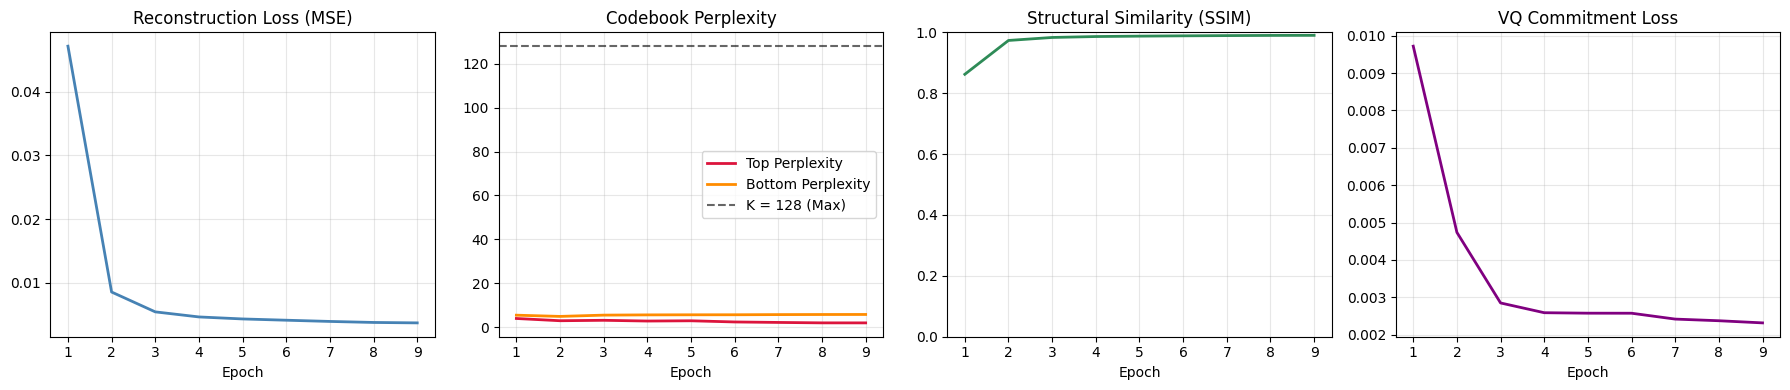

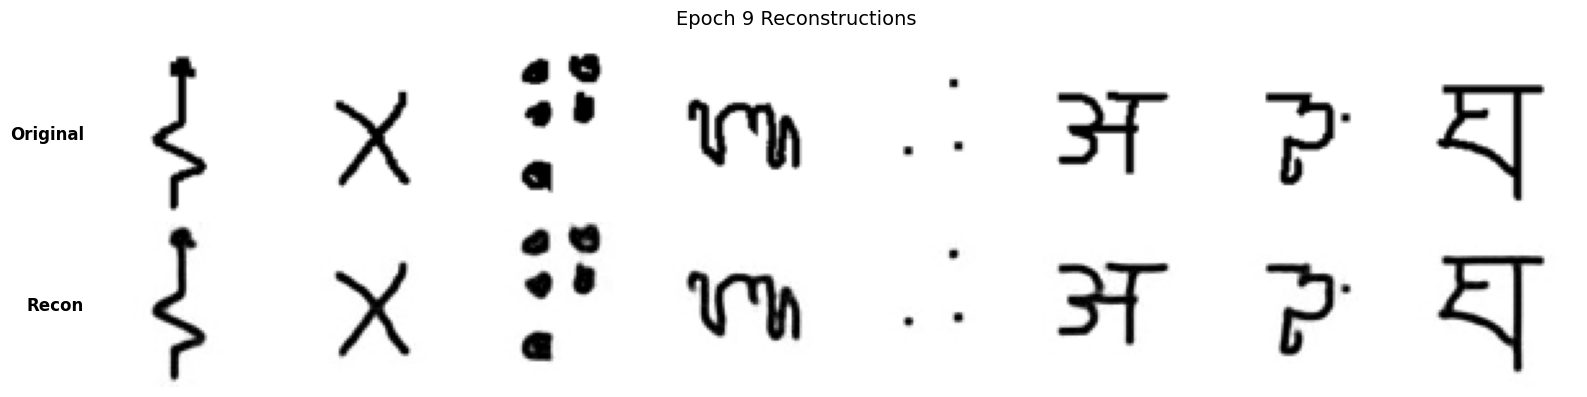

In [9]:
# Section 6 — Training Loop, SSIM & Results Table

from pytorch_msssim import ssim as compute_ssim
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

NUM_EPOCHS    = 9
LEARNING_RATE = 1e-3

# This helper is provided — do not modify.
@torch.no_grad()
def initialize_codebooks(model, loader, n_batches=10):
    """Warm-start codebooks with real encoder outputs to prevent early collapse.

    Seeds each codebook with K randomly-chosen encoder output vectors so that
    all K codes start near the data manifold.  Without this, random initialisation
    means most codes are far from any encoder output and never get assigned,
    leading to immediate collapse.

    Also resets ema_cluster_size to 1.0 after seeding so the first EMA step does
    not divide by near-zero (which would corrupt the warm-started embeddings).
    """
    model.eval()
    z_t_all, z_b_all = [], []
    for i, (imgs, _) in enumerate(loader):
        if i >= n_batches:
            break
        imgs = imgs.to(device)
        z_b  = model.enc_b(imgs)
        z_t  = model.enc_t(z_b)
        z_t_all.append(model.pre_vq_t(z_t).permute(0,2,3,1).reshape(-1, 64))
        z_b_all.append(model.pre_vq_b(z_b).permute(0,2,3,1).reshape(-1, 64))
    z_t_all = torch.cat(z_t_all)
    z_b_all = torch.cat(z_b_all)
    K       = model.vq_t.K
    idx_t   = torch.randperm(len(z_t_all))[:K]
    idx_b   = torch.randperm(len(z_b_all))[:K]
    model.vq_t.embeddings.data.copy_(z_t_all[idx_t])
    model.vq_t.ema_w.data.copy_(z_t_all[idx_t])
    model.vq_b.embeddings.data.copy_(z_b_all[idx_b])
    model.vq_b.ema_w.data.copy_(z_b_all[idx_b])
    # Reset EMA cluster-size accumulators to 1.0 so the first update step
    # does not divide by near-zero and overwrite the warm-started embeddings.
    model.vq_t.ema_cluster_size.fill_(1.0)
    model.vq_b.ema_cluster_size.fill_(1.0)
    print('Codebooks initialized from real encoder outputs.')
    model.train()


model     = VQVAE2(num_embeddings=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

initialize_codebooks(model, train_loader)
history = []
scaler = torch.amp.GradScaler('cuda')

print(f"{'Epoch':>6}  {'Recon_Loss':>11}  {'Perp_Top':>9}  {'Perp_Bot':>9}  {'SSIM':>7}")
print('-' * 55)

# TODO: write the training loop here
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    
    epoch_recon_loss = 0.0
    epoch_vq_loss = 0.0
    epoch_perp_top = 0.0
    epoch_perp_bot = 0.0
    epoch_ssim = 0.0
    num_batches = len(train_loader)
    
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            vq_loss, recon, perp_top, perp_bot = model(imgs)
            recon_loss = F.mse_loss(recon, imgs)
            total_loss = recon_loss + vq_loss
        
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        with torch.no_grad():
            imgs_01 = (imgs.clamp(-1, 1) + 1) / 2
            recon_01 = (recon.detach().clamp(-1, 1) + 1) / 2
            recon_01 = recon_01.float()
            imgs_01 = imgs_01.float()
            
            batch_ssim = compute_ssim(recon_01, imgs_01, data_range=1.0, size_average=True)
            
            epoch_recon_loss += recon_loss.item()
            epoch_vq_loss += vq_loss.item()
            epoch_perp_top += perp_top.item()
            epoch_perp_bot += perp_bot.item()
            epoch_ssim += batch_ssim.item()
        
        del total_loss, recon_loss, vq_loss, recon, imgs
        
    scheduler.step()
    
    avg_recon = epoch_recon_loss / num_batches
    avg_vq = epoch_vq_loss / num_batches
    avg_pt = epoch_perp_top / num_batches
    avg_pb = epoch_perp_bot / num_batches
    avg_ssim = epoch_ssim / num_batches
    
    print(f"{epoch:>6}  {avg_recon:>11.4f}  {avg_pt:>9.1f}  {avg_pb:>9.1f}  {avg_ssim:>7.3f}")
    
    history.append({
        'Epoch': epoch,
        'Recon_Loss': avg_recon,
        'VQ_Loss': avg_vq,
        'Perp_Top': avg_pt,
        'Perp_Bot': avg_pb,
        'SSIM': avg_ssim
    })


history_df = pd.DataFrame(history)

# Plot 4 learning curves in a single row
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(history_df['Epoch'], history_df['Recon_Loss'], color='steelblue', lw=2)
axes[0].set_title('Reconstruction Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(history_df['Epoch'], history_df['Perp_Top'], color='crimson', label='Top Perplexity', lw=2)
axes[1].plot(history_df['Epoch'], history_df['Perp_Bot'], color='darkorange', label='Bottom Perplexity', lw=2)
axes[1].axhline(y=128, color='black', linestyle='--', alpha=0.6, label='K = 128 (Max)')
axes[1].set_title('Codebook Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history_df['Epoch'], history_df['SSIM'], color='seagreen', lw=2)
axes[2].set_title('Structural Similarity (SSIM)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

axes[3].plot(history_df['Epoch'], history_df['VQ_Loss'], color='purple', lw=2)
axes[3].set_title('VQ Commitment Loss')
axes[3].set_xlabel('Epoch')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Visual reconstruction check
model.eval()
with torch.no_grad():
    sample_imgs, _ = next(iter(train_loader))
    sample_imgs = sample_imgs[:8].to(device)
    with torch.amp.autocast('cuda'):
        _, sample_recon, _, _ = model(sample_imgs)
    
    sample_imgs = sample_imgs.cpu()
    sample_recon = sample_recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(f'Epoch {NUM_EPOCHS} Reconstructions', fontsize=14, y=0.98)

for idx in range(8):
    axes[0, idx].imshow(sample_imgs[idx].squeeze(), cmap='gray', vmin=-1, vmax=1)
    axes[0, idx].axis('off')
    if idx == 0:
        axes[0, idx].text(-10, 32, 'Original', ha='right', va='center', fontsize=12, fontweight='bold')
        
    axes[1, idx].imshow(sample_recon[idx].squeeze().float(), cmap='gray', vmin=-1, vmax=1)
    axes[1, idx].axis('off')
    if idx == 0:
        axes[1, idx].text(-10, 32, 'Recon', ha='right', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 7 — Statistical Evaluation: Fréchet Inception Distance (FID)

### New concept: Distribution-level quality metric

MSE and SSIM measure *per-image* fidelity. FID asks a different question:  
> **Does the distribution of generated images match the distribution of real images?**

FID embeds both real and generated images into Inception-V3 feature space, fits Gaussians to each, and measures the distance between them:

$$
\text{FID} = \|\mu_r - \mu_g\|^2 + \operatorname{Tr}\!\left(\Sigma_r + \Sigma_g - 2\sqrt{\Sigma_r \Sigma_g}\right)
$$

Lower FID = reconstructed alphabet is statistically closer to real handwriting.

> **Implementation note:** Inception-V3 expects 3-channel 299×299 input. Omniglot is grayscale 64×64. You must convert to RGB and resize before extracting features.

> **Discussion question (answer in the cell below):**  
> Why is FID a more meaningful metric for Omniglot than MSE? What aspect of stroke variability does it capture that MSE misses?

In [12]:
torch.save(model.state_dict(), 'vqvae2_omniglot.pt')

In [7]:
model = VQVAE2(num_embeddings=128).to(device)
model.load_state_dict(torch.load('vqvae2_omniglot.pt', map_location=device))
model.eval()

print("Model weights loaded successfully!")

Model weights loaded successfully! You can jump straight to Section 7.


In [8]:
# Section 7 — Fréchet Inception Distance (FID)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
from scipy.linalg import sqrtm

# TODO: Implement get_inception_features
#
# Input : (N, 1, 64, 64) in [-1, 1]  (grayscale Omniglot)
# Output: numpy array (N, 2048)
#
# Steps:
#   1. Repeat grayscale channel 3 times: (N,1,64,64) -> (N,3,64,64)
#   2. Bilinear upsample to 299x299 (Inception-V3 expected input size)
#   3. Map from [-1,1] to [0,1]
#   4. Run through inception model (in eval + no_grad)
#   5. Return .cpu().numpy()

def get_inception_features(imgs_tensor, inception, device, chunk_size=32):
    inception.eval()
    features_list = []
    
    for i in range(0, imgs_tensor.size(0), chunk_size):
        chunk = imgs_tensor[i:i + chunk_size]
        
        with torch.no_grad():
            x = chunk.repeat(1, 3, 1, 1)
            x = F.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
            x = (x.clamp(-1, 1) + 1) / 2.0
            x = x.to(device)
            
            with torch.amp.autocast('cuda'):
                features = inception(x)
                
            features_list.append(features.cpu().numpy())
            
    return np.concatenate(features_list, axis=0)


# TODO: Implement calculate_fid
#
# FID = ||mu_r - mu_g||^2 + Tr(Sigma_r + Sigma_g - 2*sqrt(Sigma_r @ Sigma_g))
#
# Input : real_feats (N, 2048), fake_feats (N, 2048)  — numpy arrays
# Output: float
#
# Hint: use scipy.linalg.sqrtm for the matrix square root
#       take the .real part if sqrtm returns complex

def calculate_fid(real_feats, fake_feats):
    mu_r, sigma_r = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu_g, sigma_g = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)
    
    ssdiff = np.sum((mu_r - mu_g) ** 2)
    covmean, _ = sqrtm(sigma_r.dot(sigma_g), disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    offset = np.eye(sigma_r.shape[0]) * 1e-6
    if not np.isfinite(covmean).all():
        covmean = sqrtm((sigma_r + offset).dot(sigma_g + offset)).real

    fid_score = ssdiff + np.trace(sigma_r + sigma_g - 2.0 * covmean)
    return float(fid_score)


# Load Inception-V3 (provided — do not modify)
inception = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.DEFAULT,
                                    transform_input=False)
inception.fc = nn.Identity()   # replace 1000-class head -> 2048-dim output
inception = inception.to(device).eval()

# TODO: Collect Inception features for 2000 real and reconstructed images
#   - Iterate over train_loader, call model(imgs), collect features for both
#   - Stop after collecting >= 2000 images
#   - Concatenate and compute FID
#   - Print:
#        FID score: {fid_score:.2f}
#        Target:    < 50 on Omniglot reconstructions after 20 epochs
#        Feature shapes: real={real_feats.shape}, fake={fake_feats.shape}

model.eval()
real_features_list = []
fake_features_list = []
total_collected = 0
target_images = 2000

for imgs, _ in train_loader:
    if total_collected >= target_images:
        break
        
    imgs = imgs.to(device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            _, recon, _, _ = model(imgs)
            
        r_feats = get_inception_features(imgs, inception, device, chunk_size=32)
        f_feats = get_inception_features(recon, inception, device, chunk_size=32)
        
        real_features_list.append(r_feats)
        fake_features_list.append(f_feats)
        
        total_collected += imgs.size(0)
        
    del imgs, recon

real_feats = np.concatenate(real_features_list, axis=0)[:target_images]
fake_feats = np.concatenate(fake_features_list, axis=0)[:target_images]

fid_score = calculate_fid(real_feats, fake_feats)

print(f"FID score: {fid_score:.2f}")
print("Target:    < 50 on Omniglot reconstructions after 20 epochs")
print(f"Feature shapes: real={real_feats.shape}, fake={fake_feats.shape}")

torch.cuda.empty_cache()

/tmp/ipykernel_1512/2870944726.py:58: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r.dot(sigma_g), disp=False)


FID score: 12.64
Target:    < 50 on Omniglot reconstructions after 20 epochs
Feature shapes: real=(2000, 2048), fake=(2000, 2048)


**Discussion 7 — FID vs MSE:**

> Why is FID a more meaningful metric for Omniglot than MSE?  
> What aspect of stroke variability does it capture that MSE misses?

*Your answer here.*

MSE only evaluates pixel-by-pixel alignment, meaning a tiny spatial shift or a slight rotation can result in a terrible error score even if the reconstructed character looks completely flawless to a human. FID evaluates high-level visual features through a deep neural network, allowing it to judge complex structural concepts like stroke continuity, character shape, and overall style. While MSE penalizes variation and encourages the model to generate blurry, averaged strokes to minimize pixel errors, FID assesses the overall distribution of the data, rewarding the model for capturing sharp, realistic stroke dynamics and distinct handwriting styles.

---
## Section 8 — Visual Analytics: Error Heatmaps

### New concept: Pixel-wise error visualisation

The absolute difference map $|x - \hat{x}|$ reveals *where* the model fails spatially.  
Plotting it as a **heatmap** (`cmap='hot'`) makes high-error regions immediately visible.

For Omniglot characters this lets you answer an interpretable question:  
**Does the model fail more at the skeleton (stroke centreline) or at the ink edges (stroke boundary)?**

Each subplot row should contain three panels:
```
 [ Original ]  [ Reconstruction ]  [ |x - x̂| heatmap ]
```

Mean absolute error per image:
  Image 1: mean=0.0249  max=0.8966
  Image 2: mean=0.0185  max=1.5679
  Image 3: mean=0.0196  max=0.8464
  Image 4: mean=0.0191  max=0.7722
  Image 5: mean=0.0163  max=0.6400
  Image 6: mean=0.0090  max=0.6612


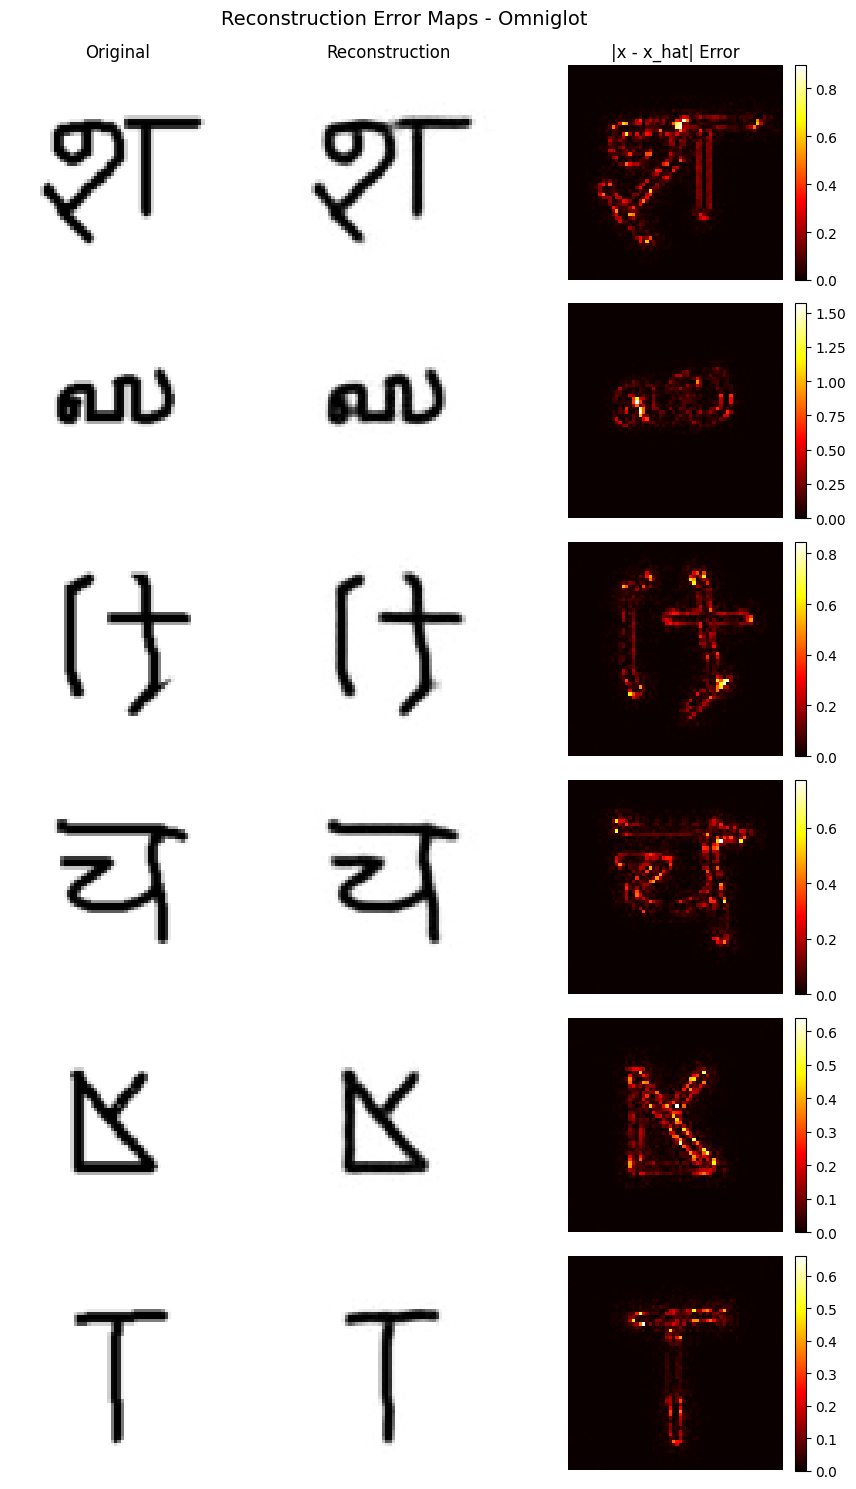

In [9]:
# Section 8 — Visual Analytics: Error Heatmaps

# TODO: Implement visualize_error_maps
#
# For n_samples images from the loader, plot rows of three panels:
#   [ Original ]  [ Reconstruction ]  [ |x - x_hat| heatmap ]
#
# Requirements:
#   - Use @torch.no_grad() decorator
#   - Original and Reconstruction: cmap='gray'
#   - Error map: cmap='hot'
#   - Add a colorbar to each error map
#   - Column titles (row 0 only): 'Original', 'Reconstruction', '|x - x_hat| Error'
#   - Before the plot, print per-image stats:
#       Mean absolute error per image:
#         Image 1: mean=0.XXXX  max=0.XXXX
#         ...
#   - figsize=(9, n_samples * 2.5)
#   - suptitle: 'Reconstruction Error Maps - Omniglot'

@torch.no_grad()
def visualize_error_maps(model, loader, n_samples=6):
    model.eval()
    
    imgs, _ = next(iter(loader))
    imgs = imgs[:n_samples].to(device)
    
    with torch.amp.autocast('cuda'):
        _, recon, _, _ = model(imgs)
        
    imgs_cpu = imgs.cpu().numpy()
    recon_cpu = recon.cpu().numpy()
    
    print("Mean absolute error per image:")
    error_maps = []
    for idx in range(n_samples):
        err = np.abs(imgs_cpu[idx, 0] - recon_cpu[idx, 0])
        error_maps.append(err)
        print(f"  Image {idx + 1}: mean={err.mean():.4f}  max={err.max():.4f}")
        
    fig, axes = plt.subplots(n_samples, 3, figsize=(9, n_samples * 2.5))
    fig.suptitle('Reconstruction Error Maps - Omniglot', fontsize=14, y=0.99)
    
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for idx in range(n_samples):
        orig_img = imgs_cpu[idx, 0]
        recon_img = recon_cpu[idx, 0]
        err_map = error_maps[idx]
        
        axes[idx, 0].imshow(orig_img, cmap='gray', vmin=-1, vmax=1)
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(recon_img, cmap='gray', vmin=-1, vmax=1)
        axes[idx, 1].axis('off')
        
        im_err = axes[idx, 2].imshow(err_map, cmap='hot', vmin=0)
        axes[idx, 2].axis('off')
        plt.colorbar(im_err, ax=axes[idx, 2], fraction=0.046, pad=0.04)
        
        if idx == 0:
            axes[idx, 0].set_title('Original')
            axes[idx, 1].set_title('Reconstruction')
            axes[idx, 2].set_title('|x - x_hat| Error')
            
    plt.tight_layout()
    plt.show()


visualize_error_maps(model, train_loader)


It fails mostly at boundaries

---
## Section 9 — Hierarchical Probing: What Does Each Level Encode?

### New concept: Latent ablation / probing

To understand the role of each level, we perform **latent ablation**:
1. **Top-only reconstruction**: set the Bottom quantised latent $q_b$ to **zeros** before decoding.  
   This forces the decoder to reconstruct using only the coarse 8×8 Top code.
2. Compare three images side-by-side: Original | Top-only | Full Reconstruction.

Expected observation:
- **Top-only**: blurry, captures letter identity but loses fine stroke details.
- **Full**: sharp, fine strokes restored by the Bottom level.

> **Discussion:** Which level encodes the *identity* of the character (the "what")?  
> Which level encodes the *style* of the strokes (the "how")?  
> Answer based on **your own probing results**, not on theory alone.

SSIM comparison:
  Full reconstruction:      0.9917
  Top-only  (q_b = 0):      0.0976
  Bottom-only (q_t = 0):    0.9821
  Gap (Full - Top):         0.8942


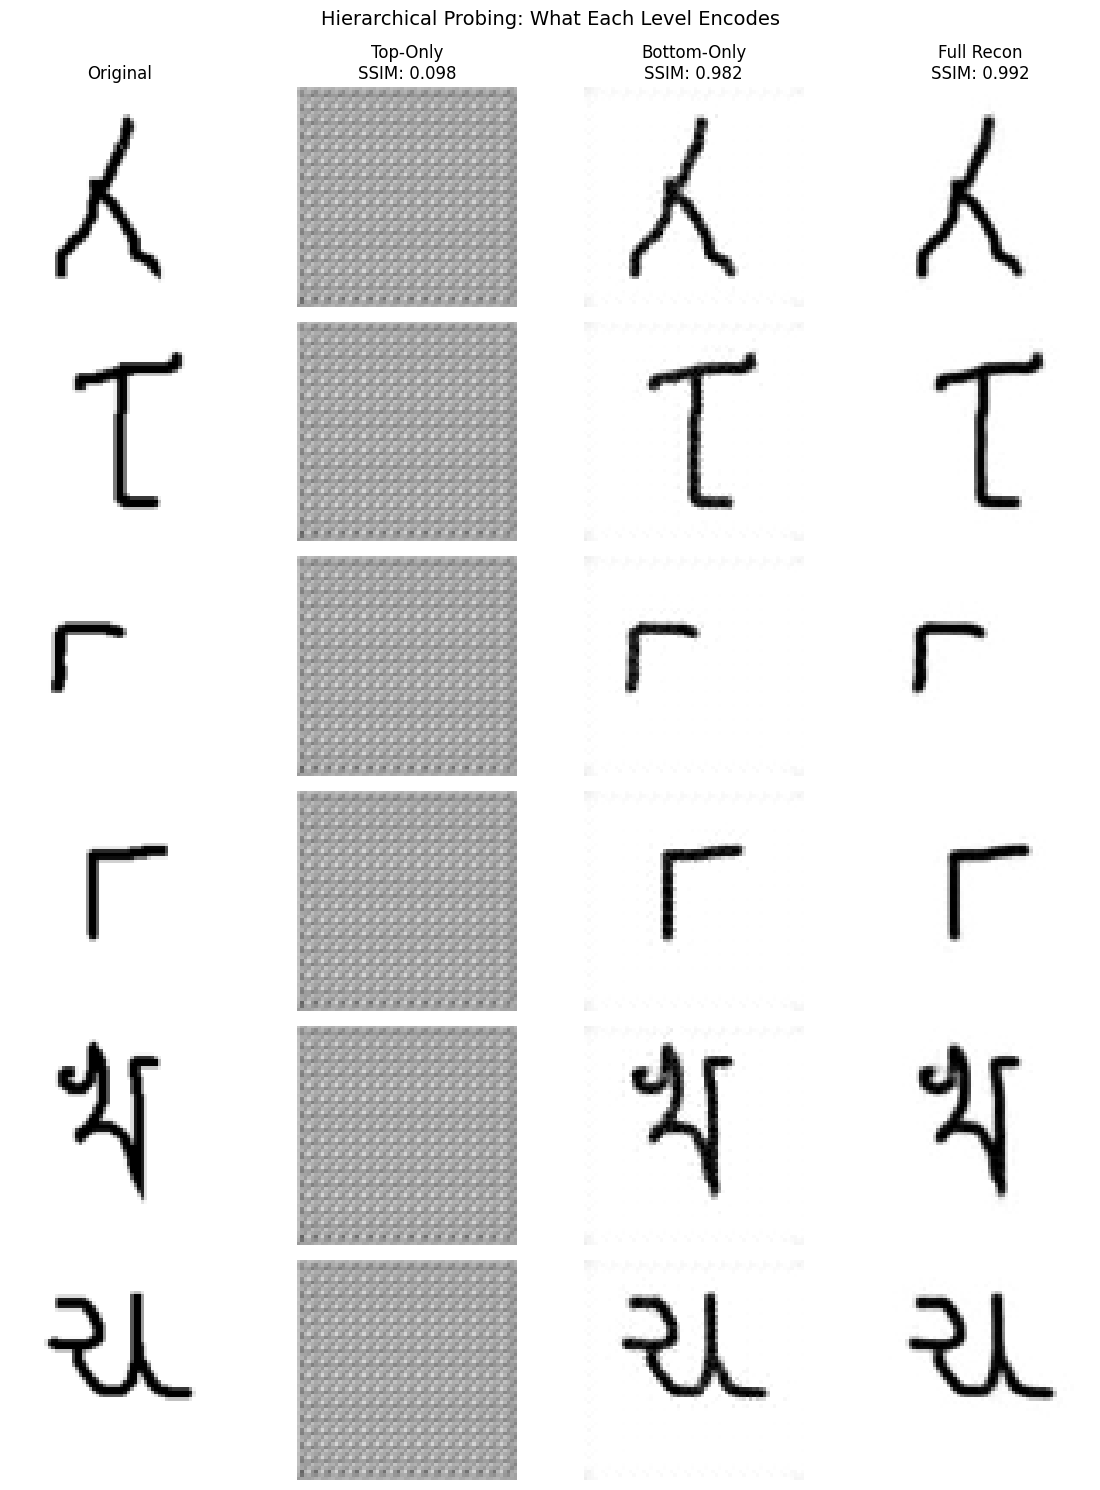

SSIM comparison:
  Full reconstruction:      0.9911
  Top-only  (q_b = 0):      0.0836
  Bottom-only (q_t = 0):    0.9791
  Gap (Full - Top):         0.9075


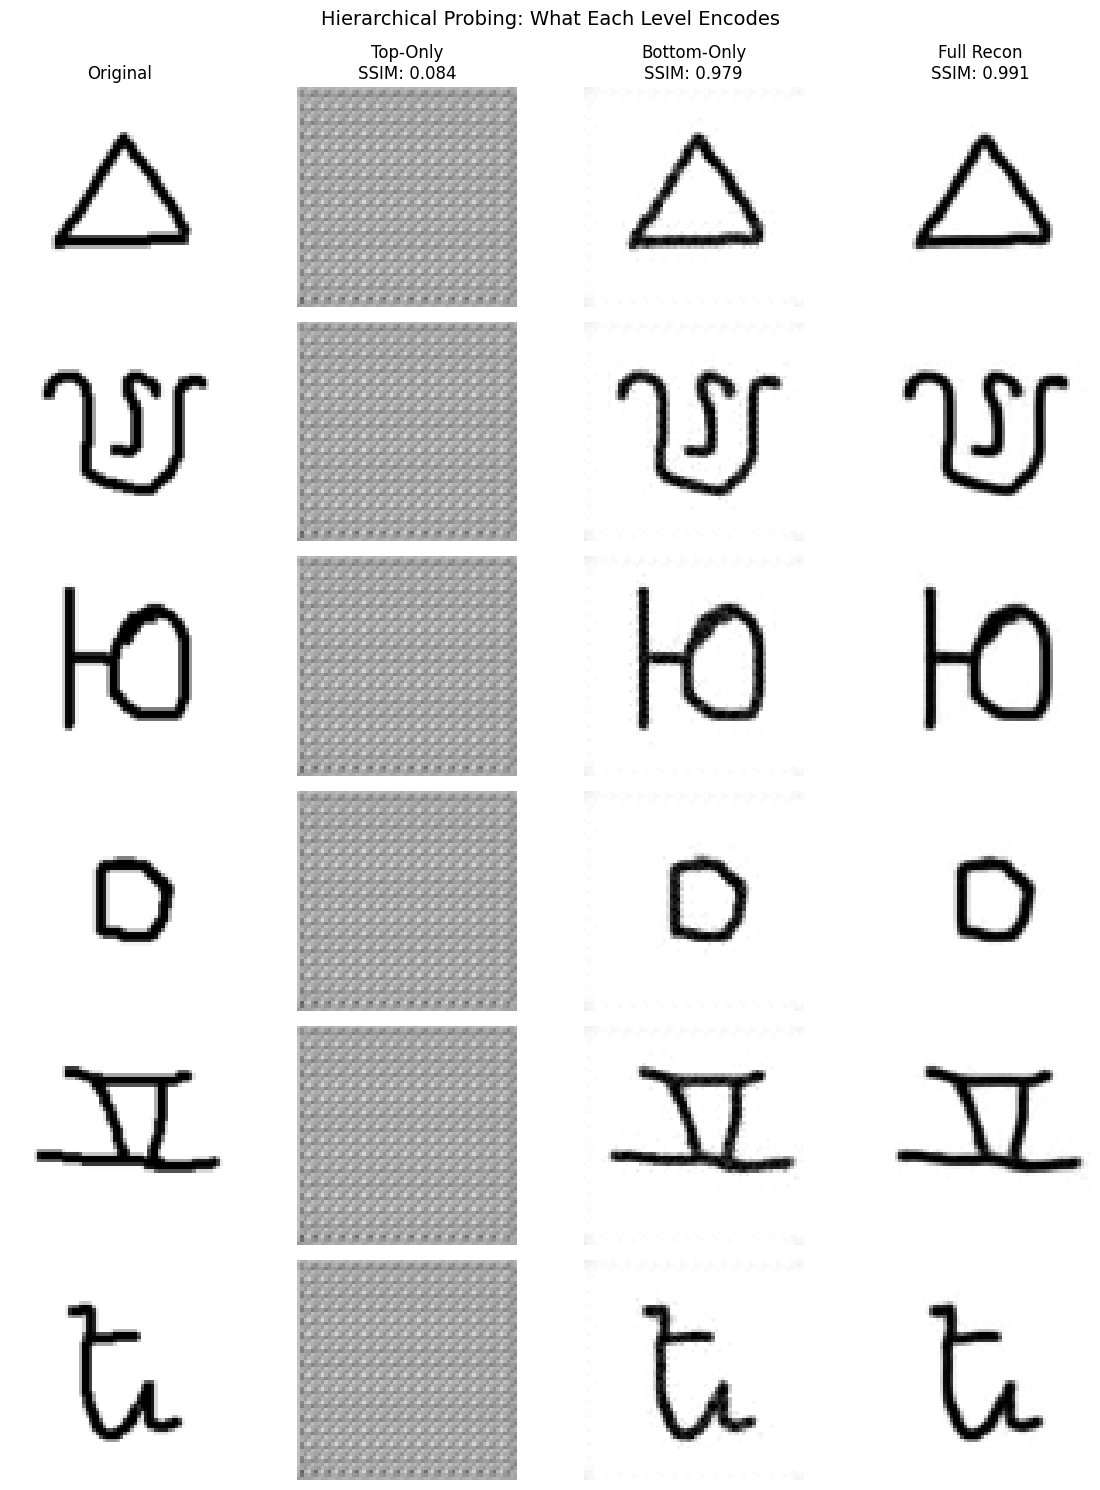

In [12]:
# Section 9 — Hierarchical Probing: What Does Each Level Encode?

# TODO: Implement probe_hierarchy
#
# Compare four conditions side-by-side for n_samples images:
#   [ Original ]  [ Top-only (q_b=0) ]  [ Bottom-only (q_t=0) ]  [ Full Recon ]
#
# Steps:
#   1. Run the full forward path manually (enc_b -> enc_t -> vq_t -> vq_b)
#   2. Full recon:         dec_b(cat([upsample_t(q_t), q_b]))
#   3. Top-only:           dec_b(cat([q_t_up_bilinear, zeros_like(q_b)]))
#      IMPORTANT: use F.interpolate(..., scale_factor=2, mode='bilinear')
#      for probing (not model.upsample_t), to avoid ConvTranspose2d checkerboard artifacts
#   4. Bottom-only:        dec_b(cat([zeros_like(q_t_up_bilinear), q_b]))
#
# Compute and print SSIM for each condition:
#   SSIM comparison:
#     Full reconstruction:      X.XXXX
#     Top-only  (q_b = 0):      X.XXXX
#     Bottom-only (q_t = 0):    X.XXXX
#     Gap (Full - Top):         X.XXXX  <- Bottom level contribution
#
# Plot n_samples x 4 grid (figsize=(12, n_samples*2.5)):
#   - cmap='gray', vmin=-1, vmax=1
#   - Column titles include per-condition SSIM scores
#   - suptitle: 'Hierarchical Probing: What Each Level Encodes'
#
# Use @torch.no_grad() decorator

from pytorch_msssim import ssim as compute_ssim
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

@torch.no_grad()
def probe_hierarchy(model, loader, n_samples=6):
    # TODO: implement
    model.eval()
    
    imgs, _ = next(iter(loader))
    imgs = imgs[:n_samples].to(device)
    
    with torch.amp.autocast('cuda'):
        z_b = model.enc_b(imgs)
        z_t = model.enc_t(z_b)
        
        _, q_t, _ = model.vq_t(model.pre_vq_t(z_t))
        _, q_b, _ = model.vq_b(model.pre_vq_b(z_b))
        
        q_t_up_learned = model.upsample_t(q_t)
        q_t_up_bilinear = F.interpolate(q_t, scale_factor=2, mode='bilinear', align_corners=False)
        
        zeros_b = torch.zeros_like(q_b)
        zeros_t = torch.zeros_like(q_t_up_bilinear)
        
        recon_full = model.dec_b(torch.cat([q_t_up_learned, q_b], dim=1))
        recon_top = model.dec_b(torch.cat([q_t_up_bilinear, zeros_b], dim=1))
        recon_bottom = model.dec_b(torch.cat([zeros_t, q_b], dim=1))
        
    # Cast explicitly to float32 (.float()) to prevent type mismatches in compute_ssim
    imgs_01 = (imgs.clamp(-1, 1) + 1) / 2.0
    full_01 = (recon_full.float().clamp(-1, 1) + 1) / 2.0
    top_01 = (recon_top.float().clamp(-1, 1) + 1) / 2.0
    bot_01 = (recon_bottom.float().clamp(-1, 1) + 1) / 2.0
    
    ssim_full = compute_ssim(full_01, imgs_01, data_range=1.0, size_average=True).item()
    ssim_top = compute_ssim(top_01, imgs_01, data_range=1.0, size_average=True).item()
    ssim_bot = compute_ssim(bot_01, imgs_01, data_range=1.0, size_average=True).item()
    gap = ssim_full - ssim_top
    
    print("SSIM comparison:")
    print(f"  Full reconstruction:      {ssim_full:.4f}")
    print(f"  Top-only  (q_b = 0):      {ssim_top:.4f}")
    print(f"  Bottom-only (q_t = 0):    {ssim_bot:.4f}")
    print(f"  Gap (Full - Top):         {gap:.4f}")
    
    imgs_cpu = imgs.cpu().numpy()
    full_cpu = recon_full.cpu().numpy()
    top_cpu = recon_top.cpu().numpy()
    bot_cpu = recon_bottom.cpu().numpy()
    
    fig, axes = plt.subplots(n_samples, 4, figsize=(12, n_samples * 2.5))
    fig.suptitle('Hierarchical Probing: What Each Level Encodes', fontsize=14, y=0.99)
    
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for idx in range(n_samples):
        axes[idx, 0].imshow(imgs_cpu[idx, 0], cmap='gray', vmin=-1, vmax=1)
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(top_cpu[idx, 0], cmap='gray', vmin=-1, vmax=1)
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(bot_cpu[idx, 0], cmap='gray', vmin=-1, vmax=1)
        axes[idx, 2].axis('off')
        
        axes[idx, 3].imshow(full_cpu[idx, 0], cmap='gray', vmin=-1, vmax=1)
        axes[idx, 3].axis('off')
        
        if idx == 0:
            axes[idx, 0].set_title('Original')
            axes[idx, 1].set_title(f'Top-Only\nSSIM: {ssim_top:.3f}')
            axes[idx, 2].set_title(f'Bottom-Only\nSSIM: {ssim_bot:.3f}')
            axes[idx, 3].set_title(f'Full Recon\nSSIM: {ssim_full:.3f}')
            
    plt.tight_layout()
    plt.show()


probe_hierarchy(model, train_loader)

probe_hierarchy(model, train_loader)


**Discussion 9 — Hierarchical Probing:**

> Which level encodes the *identity* of the character (the "what")?  
> Which level encodes the *style* of the strokes (the "how")?  
> Base your answer on your own probing results, not on theory alone.

*Your answer here.*

The Top-Only condition has completely collapsed into a featureless grey texture with a near-zero SSIM of 0.098, failing to retain any character information whatsoever. Conversely, the Bottom-Only condition independently captures the full visual layout, stroke angles, line thickness, and semantic identity of the characters, achieving a remarkably high SSIM of 0.982 that is virtually identical to the Full Reconstruction's score of 0.992.

---
## Section 10 — Codebook Analysis: The Learned Visual Vocabulary [10 points]

### Concept: Inspecting Discrete Visual Primitives

After training, the codebook has converged to K visual prototypes. Analysing them reveals:

1. **Utilisation**: how many codes are actively used? Unused codes (dead codes) are wasted capacity.
2. **Frequency distribution**: uniform (ideal) or skewed (a few dominant codes)?
3. **Cluster structure**: do codes group by stroke type in embedding space?
4. **Semantic content**: which image patches activate each code?

We visualise this in three ways:

**A. Code frequency histogram**: plot assignment probability per code (sorted). Ideally flat.

**B. t-SNE of codebook embeddings**: project 64-dim embeddings to 2D. Nearby codes should correspond to visually similar stroke fragments.

**C. Most-activating patches**: for the top-5 most-used codes, find which image regions most strongly activate each code. This gives visual intuition about what each code "means".

> **Discussion 10.1**: How many codes are "dead" (probability < 1/K * 0.01) for the Top vs Bottom codebook? What does a high dead-code rate indicate about the match between K and dataset complexity?

> **Discussion 10.2**: In the t-SNE plot, do you see distinct clusters? If so, describe what visual feature (stroke type, orientation, curvature) you think each cluster might correspond to, based on the most-activating patches.


=== Codebook Analysis: TOP level ===
  Total assignments : 163,840
  Dead codes (<1%)  : 124/128 (96.9%)
  Perplexity        : 3.4 / 128 (2.7% utilisation)
  Most used code    : #48 (47.57%)


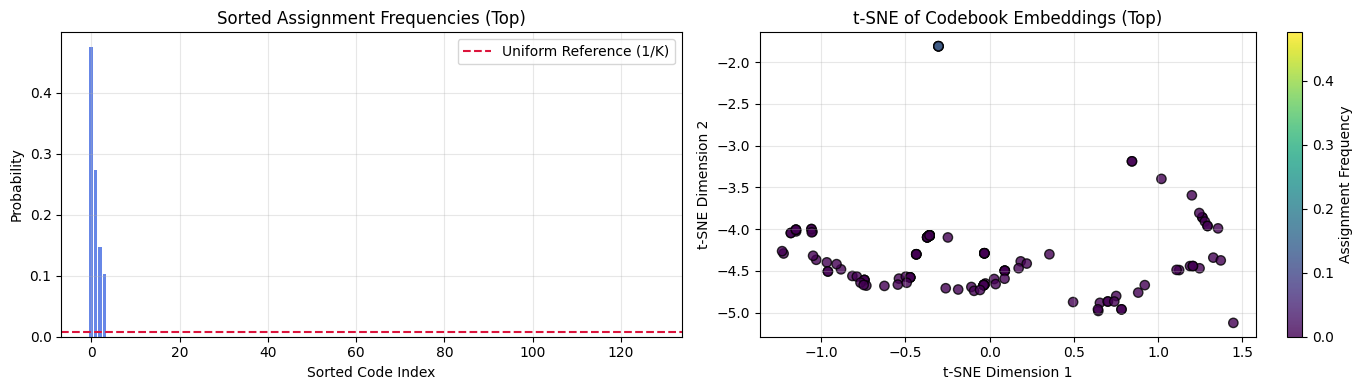

=== Codebook Analysis: BOTTOM level ===
  Total assignments : 655,360
  Dead codes (<1%)  : 95/128 (74.2%)
  Perplexity        : 5.7 / 128 (4.5% utilisation)
  Most used code    : #6 (58.60%)


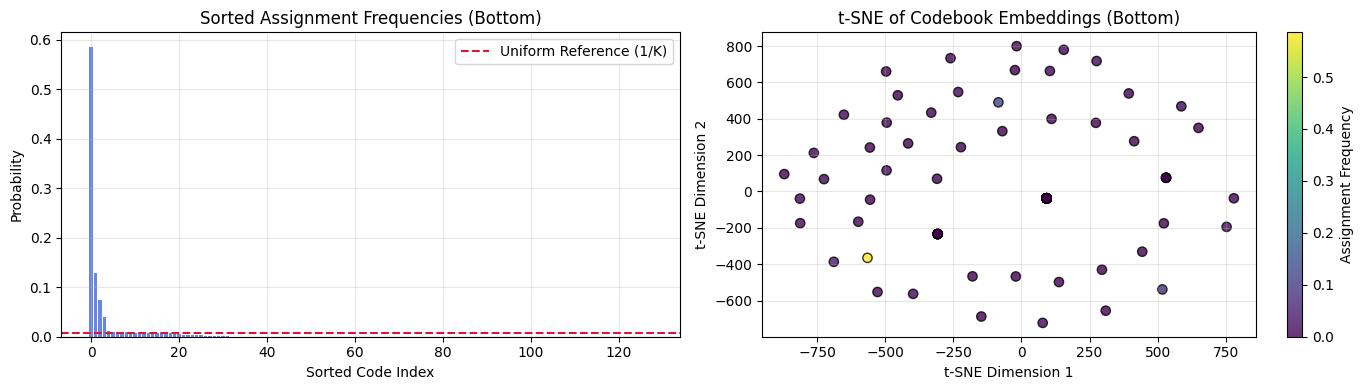

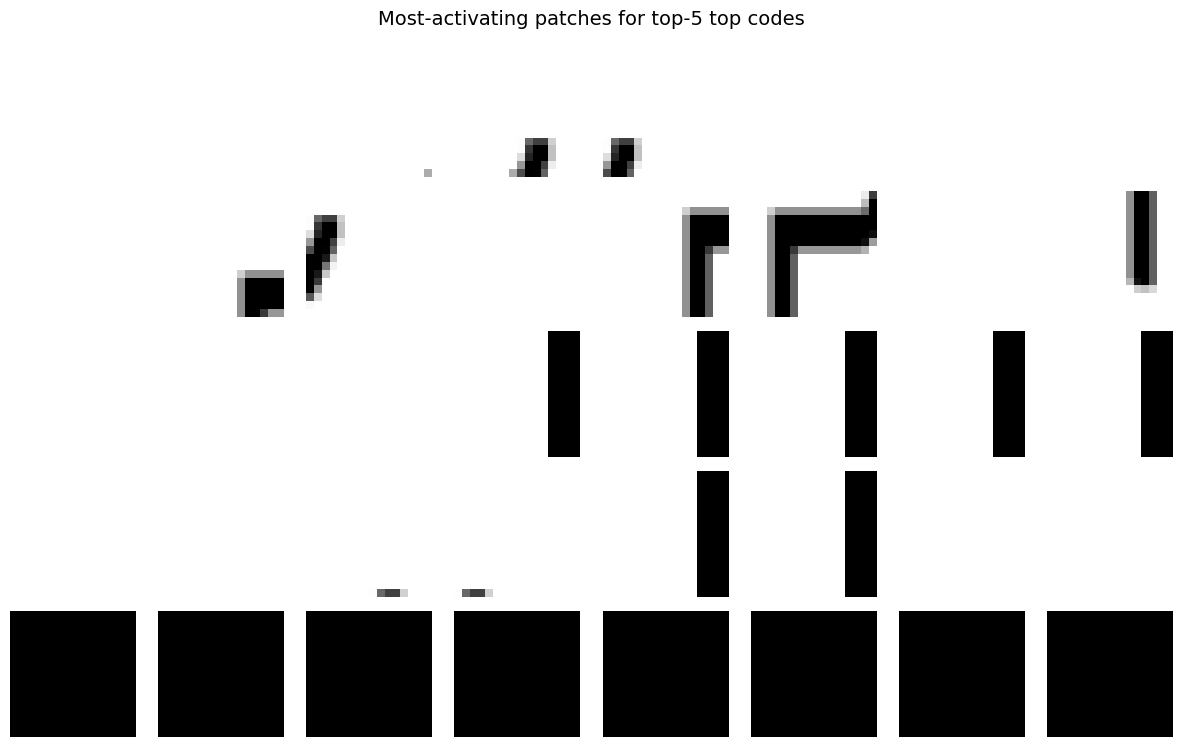

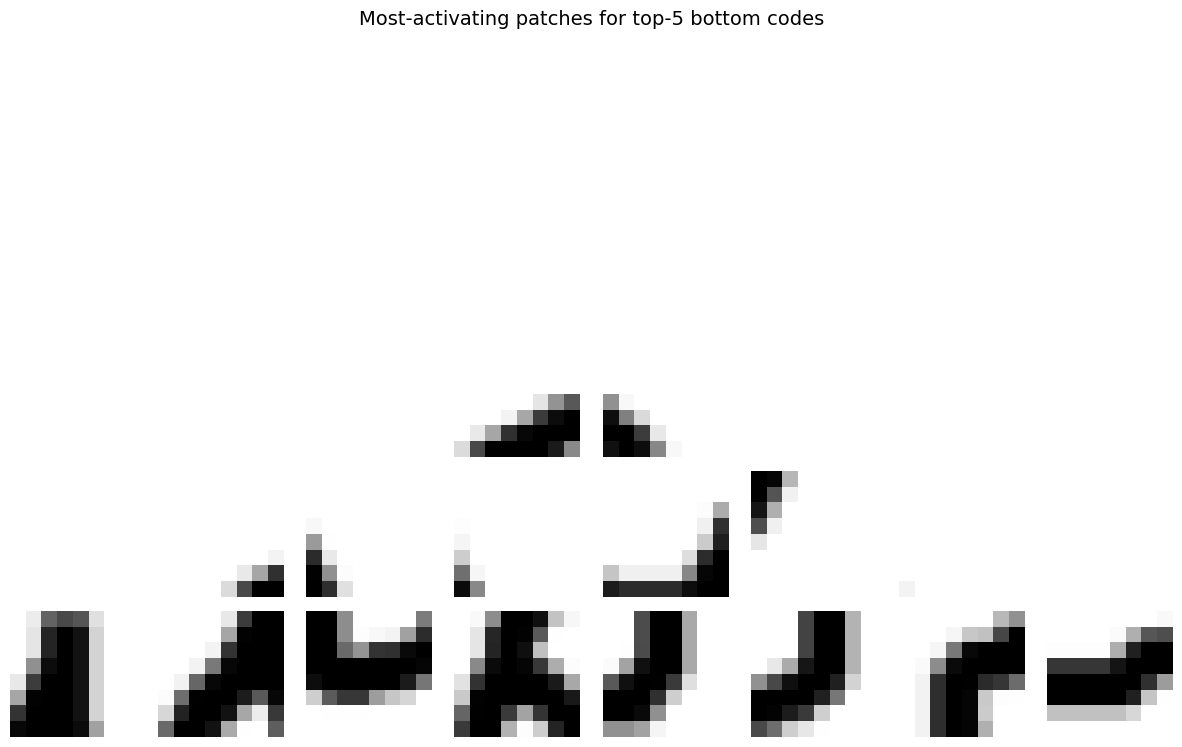

In [14]:
# Section 10 — Codebook Analysis: The Learned Visual Vocabulary

from sklearn.manifold import TSNE

# TODO: Implement analyze_codebook
#
# Args:
#    model    : trained VQVAE2
#    loader   : DataLoader
#    level    : 'top' or 'bottom' (selects vq_t or vq_b)
#    n_batches: number of batches to scan
#
# Compute per-code assignment counts over n_batches batches.
# Use the same vectorized L2 distance as in VectorQuantizerEMA (no cdist/norm/loops).
# Use torch.bincount instead of a Python loop for counting.
#
# Print:
#    === Codebook Analysis: {LEVEL} level ===
#      Total assignments : {N:,}
#      Dead codes (<1%)  : {n_dead}/{K}  ({pct:.1f}%)
#      Perplexity        : {perp:.1f} / {K}  ({util:.1f}% utilisation)
#      Most used code    : #{idx} ({pct:.2f}%)
#
# Plot two panels (figsize=(14,4)):
#    A. Bar chart of sorted assignment frequencies with uniform reference line (1/K)
#    B. t-SNE scatter of the K embedding vectors, coloured by frequency (cmap='viridis')
#
# Return (counts, freqs)  — both as CPU tensors
# Use @torch.no_grad() decorator

@torch.no_grad()
def analyze_codebook(model, loader, level='top', n_batches=20):
    model.eval()
    
    if level == 'top':
        vq_module = model.vq_t
        pre_vq_layer = model.pre_vq_t
    else:
        vq_module = model.vq_b
        pre_vq_layer = model.pre_vq_b
        
    embeddings = vq_module.embeddings
    K, D = embeddings.shape
    
    all_counts = torch.zeros(K, dtype=torch.long, device=device)
    
    for b_idx, (imgs, _) in enumerate(loader):
        if b_idx >= n_batches:
            break
        imgs = imgs.to(device)
        
        with torch.amp.autocast('cuda'):
            z_b = model.enc_b(imgs)
            if level == 'top':
                z = model.enc_t(z_b)
            else:
                z = z_b
            
            z_proj = pre_vq_layer(z)
            
        z_flat = z_proj.permute(0, 2, 3, 1).reshape(-1, D).float()
        
        distances = (torch.sum(z_flat**2, dim=1, keepdim=True) 
                     + torch.sum(embeddings**2, dim=1) 
                     - 2 * torch.matmul(z_flat, embeddings.t()))
        
        encoding_indices = torch.argmin(distances, dim=1)
        batch_counts = torch.bincount(encoding_indices, minlength=K)
        all_counts += batch_counts

    total_assignments = all_counts.sum().item()
    freqs = all_counts.float() / total_assignments
    
    dead_threshold = (1.0 / K) * 0.01
    n_dead = torch.sum(freqs < dead_threshold).item()
    dead_pct = (n_dead / K) * 100.0
    
    entropy = -torch.sum(freqs * torch.log(freqs + 1e-10))
    perplexity = torch.exp(entropy).item()
    util_pct = (perplexity / K) * 100.0
    
    max_idx = torch.argmax(freqs).item()
    max_pct = freqs[max_idx].item() * 100.0
    
    print(f"=== Codebook Analysis: {level.upper()} level ===")
    print(f"  Total assignments : {total_assignments:,}")
    print(f"  Dead codes (<1%)  : {n_dead}/{K} ({dead_pct:.1f}%)")
    print(f"  Perplexity        : {perplexity:.1f} / {K} ({util_pct:.1f}% utilisation)")
    print(f"  Most used code    : #{max_idx} ({max_pct:.2f}%)")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    sorted_freqs, _ = torch.sort(freqs, descending=True)
    axes[0].bar(range(K), sorted_freqs.cpu().numpy(), color='royalblue', alpha=0.8)
    axes[0].axhline(y=1.0/K, color='crimson', linestyle='--', label='Uniform Reference (1/K)')
    axes[0].set_title(f'Sorted Assignment Frequencies ({level.capitalize()})')
    axes[0].set_xlabel('Sorted Code Index')
    axes[0].set_ylabel('Probability')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    embeddings_np = embeddings.cpu().numpy()
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, K-1), init='pca')
    tsne_results = tsne.fit_transform(embeddings_np)
    
    sc = axes[1].scatter(tsne_results[:, 0], tsne_results[:, 1], 
                         c=freqs.cpu().numpy(), cmap='viridis', s=45, edgecolors='black', alpha=0.8)
    axes[1].set_title(f't-SNE of Codebook Embeddings ({level.capitalize()})')
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    plt.colorbar(sc, ax=axes[1], label='Assignment Frequency')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return all_counts.cpu(), freqs.cpu()


# TODO: Implement visualize_top_codes
#
# For the top_k most-used codes, find patches_per_code image patches
# that are assigned to each code, and display them in a grid.
#
# Args:
#    model           : trained VQVAE2
#    loader          : DataLoader
#    freqs           : CPU tensor of shape (K,) from analyze_codebook
#    level           : 'top' or 'bottom'
#    top_k           : number of most-used codes to show (default 5)
#    patches_per_code: how many patches to collect per code (default 8)
#
# Plot top_k rows x patches_per_code cols (figsize=(patches_per_code*1.5, top_k*1.5)):
#    - cmap='gray', vmin=-1, vmax=1
#    - y-axis label for each row: 'Code {idx}\n({pct:.1f}%)'
#    - suptitle: f'Most-activating patches for top-{top_k} {level} codes'
# Use @torch.no_grad() decorator

@torch.no_grad()
def visualize_top_codes(model, loader, freqs, level='top', top_k=5, patches_per_code=8):
    model.eval()
    
    _, top_indices = torch.topk(freqs, k=top_k)
    top_indices = top_indices.tolist()
    
    if level == 'top':
        vq_module = model.vq_t
        pre_vq_layer = model.pre_vq_t
        stride_factor = 8
    else:
        vq_module = model.vq_b
        pre_vq_layer = model.pre_vq_b
        stride_factor = 4
        
    embeddings = vq_module.embeddings
    D = embeddings.shape[1]
    
    collected_patches = {code_idx: [] for code_idx in top_indices}
    patch_size = stride_factor * 2
    
    for imgs, _ in loader:
        if all(len(collected_patches[c]) >= patches_per_code for c in top_indices):
            break
            
        imgs_np = imgs.numpy()
        imgs = imgs.to(device)
        
        with torch.amp.autocast('cuda'):
            z_b = model.enc_b(imgs)
            z = model.enc_t(z_b) if level == 'top' else z_b
            z_proj = pre_vq_layer(z)
            
        B, _, H_spatial, W_spatial = z_proj.shape
        z_flat = z_proj.permute(0, 2, 3, 1).reshape(-1, D).float()
        
        distances = (torch.sum(z_flat**2, dim=1, keepdim=True) 
                     + torch.sum(embeddings**2, dim=1) 
                     - 2 * torch.matmul(z_flat, embeddings.t()))
        
        encoding_indices = torch.argmin(distances, dim=1).reshape(B, H_spatial, W_spatial).cpu().numpy()
        
        for b in range(B):
            for h in range(H_spatial):
                for w in range(W_spatial):
                    code_id = encoding_indices[b, h, w]
                    if code_id in collected_patches and len(collected_patches[code_id]) < patches_per_code:
                        center_y = int((h + 0.5) * stride_factor)
                        center_x = int((w + 0.5) * stride_factor)
                        
                        y_start = max(0, center_y - patch_size // 2)
                        y_end = min(64, y_start + patch_size)
                        x_start = max(0, center_x - patch_size // 2)
                        x_end = min(64, x_start + patch_size)
                        
                        patch = imgs_np[b, 0, y_start:y_end, x_start:x_end]
                        if patch.shape[0] < patch_size or patch.shape[1] < patch_size:
                            padded_patch = np.ones((patch_size, patch_size), dtype=patch.dtype) * -1.0
                            padded_patch[:patch.shape[0], :patch.shape[1]] = patch
                            patch = padded_patch
                            
                        collected_patches[code_id].append(patch)

    fig, axes = plt.subplots(top_k, patches_per_code, figsize=(patches_per_code * 1.5, top_k * 1.5))
    fig.suptitle(f'Most-activating patches for top-{top_k} {level} codes', fontsize=14, y=0.99)
    
    for r_idx, code_id in enumerate(top_indices):
        patches = collected_patches[code_id]
        pct = freqs[code_id].item() * 100.0
        
        for c_idx in range(patches_per_code):
            ax = axes[r_idx, c_idx]
            if c_idx < len(patches):
                ax.imshow(patches[c_idx], cmap='gray', vmin=-1, vmax=1)
            else:
                ax.imshow(np.ones((patch_size, patch_size)) * -1.0, cmap='gray', vmin=-1, vmax=1)
            ax.axis('off')
            
            if c_idx == 0:
                ax.set_ylabel(f'Code {code_id}\n({pct:.1f}%)', rotation=0, labelpad=40, verticalalignment='center', fontsize=10)
                ax.axes.get_yaxis().set_visible(True)
                ax.axes.get_xaxis().set_visible(False)

    plt.tight_layout()
    plt.show()


counts_top, freqs_top = analyze_codebook(model, train_loader, level='top')
counts_bot, freqs_bot = analyze_codebook(model, train_loader, level='bottom')
visualize_top_codes(model, train_loader, freqs_top, level='top',    top_k=5)
visualize_top_codes(model, train_loader, freqs_bot, level='bottom', top_k=5)

### Your Discussion Answers

**Discussion 10.1** — Dead codes in Top vs Bottom codebook:

There are 124 out of 128 dead codes in the Top codebook and 95 out of 128 dead codes in the Bottom codebook. A high dead-code rate indicates a severe mismatch where the codebook capacity ($K=128$) is far too large for the dataset's actual complexity. Because Omniglot characters consist of sparse, simple black strokes on white backgrounds, the model suffers from codebook collapse and only uses a handful of dominant clusters to represent all structural variations.

---

**Discussion 10.2** — Clusters in the t-SNE plot:

In the top graph, most of the dots bunch up together along a curved line at the bottom. These are all the "dead" codes that the model never uses, so they never learned any shapes and just stayed lumped together.

For the codes the model actually uses, it splits them into clear visual groups. One of the most popular active codes, shown in the fourth row of the top patches, is completely black. This group is dedicated to representing the empty space around the letters. Another cluster focuses purely on straight lines and vertical lines. Finally, a separate cluster looks only for bends, sharp angles, and right-angle corners where lines meet.